# Batch Species Parameter Tuning

A smaller, memory-safe workflow for tuning one representative species and then applying the chosen parameters across species.

The intended path is:

1. Load the manifest helpers.
2. Choose a tuning species and a small/random individual subset.
3. Prepare projections once for that tuning species.
4. Sweep `d_embed`, `N`, `tau_seconds`, and inspect suggested `M`.
5. Set final batch parameters.
6. Run species one at a time. Each species is saved before the next begins, including a streaming `frame_cluster_assignments.csv` under that species' `final_outputs` directory.


In [349]:
from pathlib import Path
import gc
import importlib
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import pipeline as pp
import pooled_user_pipeline
importlib.reload(pooled_user_pipeline)
from pooled_user_pipeline import (
    assign_pooled_states_from_projections,
    compute_pooled_slow_modes,
    entropy_gap_pooled_projections,
    prepare_pooled_individual_projections,
    projection_sample_for_tuning,
    run_species_batch,
)


## Data Setup

Edit only the paths if your Dataverse export moved. The rest of this cell defines the same lightweight manifest and loading helpers used by the batch runner.


In [350]:
dataverse_root = Path('/Users/meganbishop/moseq_dataverse')
keypoint_root = dataverse_root / 'keypoint_moseq'
manifest_path = keypoint_root / 'manifest_by_species.csv'
metadata_path = keypoint_root / 'metadata.json'
source_dir = dataverse_root / 'data_files'

manifest = pd.read_csv(manifest_path)
manifest = manifest[manifest['status'].isin(['ok', 'exists'])].copy()
manifest['subject'] = manifest['subject'].astype(str)

with open(metadata_path) as f:
    keypoint_metadata = json.load(f)

available_species = sorted(manifest['species_folder'].dropna().unique())
print('Available species folders:')
print('\n'.join(f'  - {s}' for s in available_species))

DATASET_CHOICES = {
    'size_normalized_coordinates': 'size_normalized_coordinates',
    'size_normalized_distances': 'size_normalized_distances',
    'egocentric_coordinates': 'coordinates',
    'egocentric_distances': 'distances',
}


def _recording_path(row):
    return dataverse_root / row['output_file']


def _source_path(row):
    return source_dir / f"{row['recording_id']}.hdf5"


def _samplerate(row):
    with h5py.File(_source_path(row), 'r') as f:
        return float(f['recording'].attrs['samplerate'])


def _slice_for(max_frames=None, stride=1):
    stop = None if max_frames is None else int(max_frames) * int(stride)
    return slice(0, stop, int(stride))


def species_subjects(species_name):
    species_manifest = manifest[manifest['species_folder'] == species_name]
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')
    return sorted(species_manifest['subject'].dropna().astype(str).unique())


def select_manifest(species_name, individual_ids=None):
    species_manifest = manifest[manifest['species_folder'] == species_name].copy()
    if species_manifest.empty:
        available = ', '.join(available_species)
        raise ValueError(f'Unknown species {species_name!r}. Available: {available}')

    if individual_ids is None:
        keep = species_subjects(species_name)
    elif isinstance(individual_ids, (str, int, float)):
        keep = [str(individual_ids)]
    else:
        keep = [str(x) for x in individual_ids]

    missing = sorted(set(keep) - set(species_subjects(species_name)))
    if missing:
        preview = ', '.join(species_subjects(species_name)[:10])
        raise ValueError(f'{species_name}: unknown individual(s) {missing}. First available: {preview}')

    return species_manifest[species_manifest['subject'].astype(str).isin(keep)].sort_values(
        ['subject', 'recording_id']
    )


def load_individual_trace(
    species_name,
    individual_id=None,
    dataset_name='coordinates',
    stride=1,
    max_frames_per_recording=None,
    dtype=np.float32,
):
    dataset = DATASET_CHOICES[dataset_name]
    subjects = species_subjects(species_name)
    if individual_id is None:
        individual_id = subjects[0]
    individual_id = str(individual_id)

    rows = select_manifest(species_name, individual_id)
    X_segments = []
    confidence_segments = []
    recording_ids = []
    samplerates = []
    segment_lengths = []
    slc = _slice_for(max_frames_per_recording, stride)

    for _, row in rows.iterrows():
        samplerates.append(_samplerate(row))
        with h5py.File(_recording_path(row), 'r') as f:
            values = f[dataset][slc]
            confidences = f['confidences'][slc]

        if values.ndim == 3:
            values = values.reshape(values.shape[0], values.shape[1] * values.shape[2])
        elif values.ndim != 2:
            raise ValueError(f'Expected 2D/3D dataset for {dataset}; got {values.shape}')

        X_segments.append(values.astype(dtype, copy=False))
        confidence_segments.append(confidences.astype(np.float32, copy=False))
        recording_ids.append(row['recording_id'])
        segment_lengths.append(values.shape[0])

    if len(set(samplerates)) != 1:
        raise ValueError(f'Multiple samplerates found for {species_name}/{individual_id}: {samplerates}')

    raw_fs = samplerates[0]
    fs = raw_fs / int(stride)
    return {
        'species_folder': species_name,
        'individual_id': individual_id,
        'dataset_name': dataset_name,
        'dataset': dataset,
        'X': np.concatenate(X_segments, axis=0),
        'confidences': np.concatenate(confidence_segments, axis=0),
        'recording_ids': recording_ids,
        'segment_lengths': np.array(segment_lengths, dtype=int),
        'raw_fs': raw_fs,
        'fs': fs,
        'stride': int(stride),
        'n_recordings': len(recording_ids),
    }


Available species folders:
  - Mus_caroli
  - Mus_musculus
  - Mus_spretus
  - Peromyscus_californicus
  - Peromyscus_gossypinus
  - Peromyscus_leucopus
  - Peromyscus_maniculatus
  - Peromyscus_polionotus


## Tuning Configuration

Use a representative species and optionally limit frames/individuals while tuning. The final batch cell can use all individuals after parameters are set.


In [351]:
tuning_species = 'Mus_caroli'
tuning_dataset = 'egocentric_coordinates'
tuning_stride = 1
tuning_max_frames_per_recording = None

# Use a subset for faster parameter scans; set to None for all individuals in the tuning species.
tuning_random_n_individuals = 15
tuning_random_seed = 14

wavelet_subsample_factor = 25
kmeans_subsample_factor = 25
n_freqs = 25
pca_max_components = 30
n_shuffles = 10

all_tuning_ids = species_subjects(tuning_species)
if tuning_random_n_individuals is None:
    tuning_individual_ids = all_tuning_ids
else:
    rng = np.random.default_rng(tuning_random_seed)
    n_sample = min(int(tuning_random_n_individuals), len(all_tuning_ids))
    tuning_individual_ids = rng.choice(all_tuning_ids, size=n_sample, replace=False).tolist()

first_row = select_manifest(tuning_species, tuning_individual_ids[0]).iloc[0]
fs = _samplerate(first_row) / int(tuning_stride)
fmin = 0.1
fmax = 60

print(f'tuning_species = {tuning_species}')
print(f'individuals = {len(tuning_individual_ids)} / {len(all_tuning_ids)}')
print(tuning_individual_ids[:10])
print(f'fs = {fs:g} Hz; f range = [{fmin:g}, {fmax:g}] Hz')


tuning_species = Mus_caroli
individuals = 15 / 15
['CAROLI-F-N-740', 'CAROLI-M-R-738', 'CAROLI-F-LR-741', 'CAROLI-F-L-741', 'CAROLI-M-R-734', 'CAROLI-F-2L-741', 'CAROLI-F-R-737', 'CAROLI-M-N-739', 'CAROLI-F-R-741', 'CAROLI-M-LR-734']
fs = 120 Hz; f range = [0.1, 60] Hz


## Prepare Projections Once

This is the expensive wavelet/PCA step for the tuning species. It remains memory-friendly by processing one individual at a time and saving projections to disk.


In [352]:
projection_result = prepare_pooled_individual_projections(
    pipeline_species=tuning_species,
    individual_ids=tuning_individual_ids,
    load_individual_trace_fn=load_individual_trace,
    dataset_name=tuning_dataset,
    stride=tuning_stride,
    max_frames_per_recording=tuning_max_frames_per_recording,
    fs=fs,
    fmin=fmin,
    fmax=fmax,
    n_freqs=n_freqs,
    output_dir=f'outputs/{tuning_species}',
    wavelet_subsample_factor=wavelet_subsample_factor,
    pca_max_components=pca_max_components,
    n_shuffles=n_shuffles,
    seed=tuning_random_seed,
    verbose=True,
)

proj_files = projection_result['proj_files']
n_kept = projection_result['n_kept']
print(f'projection files = {len(proj_files)}')
print(f'kept PCs = {n_kept}')


Pass 1/3: compute each individual's wavelets, keep every 25 row for shared PCA
  [1/15] CAROLI-F-N-740: X=(648024, 75)
  [2/15] CAROLI-M-R-738: X=(648024, 75)
  [3/15] CAROLI-F-LR-741: X=(648024, 75)
  [4/15] CAROLI-F-L-741: X=(648024, 75)
  [5/15] CAROLI-M-R-734: X=(648024, 75)
  [6/15] CAROLI-F-2L-741: X=(432016, 75)
  [7/15] CAROLI-F-R-737: X=(648024, 75)
  [8/15] CAROLI-M-N-739: X=(648024, 75)
  [9/15] CAROLI-F-R-741: X=(648024, 75)
  [10/15] CAROLI-M-LR-734: X=(432016, 75)
  [11/15] CAROLI-M-L-734: X=(648024, 75)
  [12/15] CAROLI-F-N-741: X=(648024, 75)
  [13/15] CAROLI-M-L-735: X=(648024, 75)
  [14/15] CAROLI-M-L-738: X=(648024, 75)
  [15/15] CAROLI-F-L-737: X=(648024, 75)
  PCA sample matrix = (371535, 1875)
  kept 15 PCs above threshold 0.388
Pass 2/2: recompute wavelets, project every frame onto shared PCA
  [1/15] CAROLI-F-N-740: projecting
  [2/15] CAROLI-M-R-738: projecting
  [3/15] CAROLI-F-LR-741: projecting
  [4/15] CAROLI-F-L-741: projecting
  [5/15] CAROLI-M-R-734: pro

## Tune Delay Embedding `d_embed`

Cao-style diagnostics can be expensive. This uses a subsampled projection matrix for a quick read; inspect where the curve begins to flatten.


In [ ]:
X_tune = projection_sample_for_tuning(proj_files, subsample_factor=20)
print(f'tuning sample shape = {X_tune.shape}')

d_values = np.arange(2, 16)
E1 = pp.cao_e1(X_tune, max_d=int(d_values.max()), tau=5, seed=tuning_random_seed)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(np.arange(2, len(E1) + 2), E1, 'o-')
ax.set_xlabel('d_embed')
ax.set_ylabel('Cao E1')
ax.set_title(tuning_species)
plt.show()

# Set this after inspecting the plot.
d_embed = 7


tuning sample shape = (464428, 15)


## Tune Cluster Count `N`

Sweep a compact set of `N` values. Larger `N` gives finer partitions but costs memory and runtime.


In [327]:
N_values = [100,150,200,250,300,350,400,500,600,800,1000]
lag_for_entropy_seconds = 5.0
lag_for_entropy = max(1, int(lag_for_entropy_seconds * fs))

N_grid, H, H_shuf = entropy_gap_pooled_projections(
    proj_files=proj_files,
    d_embed=d_embed,
    N_values=N_values,
    lag=lag_for_entropy,
    framerate=fs,
    kmeans_subsample_factor=kmeans_subsample_factor,
    seed=tuning_random_seed,
    n_init=5,
    verbose=True,
)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(N_grid, H_shuf - H, 'o-')
ax.set_xlabel('N clusters')
ax.set_ylabel('entropy gap')
ax.set_title(tuning_species)
plt.show()

# Set this after inspecting the sweep.
N = 300


## Tune Lag `tau_seconds` and Basin Count `M`

Assign states once for the chosen `d_embed` and `N`, then inspect the eigenvalue spectrum across candidate lags.


In [328]:
state_result = assign_pooled_states_from_projections(
    proj_files=proj_files,
    d_embed=d_embed,
    N=N,
    output_dir=f'outputs/tuning/{tuning_species}',
    kmeans_subsample_factor=kmeans_subsample_factor,
    seed=tuning_random_seed,
    kmeans_n_init=20,
    verbose=True,
)
states_list = state_result['states_list']
state_files = state_result['state_files']


Fitting shared k-means: d_embed=7, N=300, sample every 25 embedded rows
  k-means sample matrix = (138240, 112)
Assigning every embedded frame to shared clusters
  [1/15] 39127.0: assigning states
  [2/15] 39128.0: assigning states
  [3/15] 38042.0: assigning states
  [4/15] 38996.0: assigning states
  [5/15] 38462.0: assigning states
  [6/15] 38998.0: assigning states
  [7/15] 38043.0: assigning states
  [8/15] 39413.0: assigning states
  [9/15] 39414.0: assigning states
  [10/15] 40095.0: assigning states
  [11/15] 40415.0: assigning states
  [12/15] 40096.0: assigning states
  [13/15] 38463.0: assigning states
  [14/15] 40419.0: assigning states
  [15/15] 38046.0: assigning states


In [330]:
# tau_values = np.array([1, 2, 3, 5, 7, 10,15], dtype=float)
# eig_rows = []
# for tau_s in tau_values:
#     lag = max(1, int(tau_s * fs))
#     T_tau = pp.make_transition_matrix(states_list, lag=lag, n_states=N)
#     evals_tau, _ = pp.leading_eigvecs(T_tau, k=10)
#     gaps = np.abs(np.diff(np.real(evals_tau[:8])))
#     suggested_M = int(np.argmax(gaps[1:]) + 2) if len(gaps) > 1 else 2
#     eig_rows.append({
#         'tau_seconds': tau_s,
#         'lag_frames': lag,
#         'lambda_2': np.real(evals_tau[1]) if len(evals_tau) > 1 else np.nan,
#         'lambda_3': np.real(evals_tau[2]) if len(evals_tau) > 2 else np.nan,
#         'lambda_4': np.real(evals_tau[3]) if len(evals_tau) > 3 else np.nan,
#         'suggested_M_by_gap': suggested_M,
#     })

# eig_df = pd.DataFrame(eig_rows)
# display(eig_df)

# fig, ax = plt.subplots(figsize=(5.5, 3.2))
# for j in range(1, 5):
#     ax.plot(eig_df['tau_seconds'], [np.real(pp.leading_eigvecs(pp.make_transition_matrix(states_list, lag=max(1, int(t * fs)), n_states=N), k=6)[0][j]) for t in tau_values], 'o-', label=f'lambda_{j+1}')
# ax.set_xlabel('tau_seconds')
# ax.set_ylabel('eigenvalue')
# ax.legend()
# plt.show()

# # Set these after inspecting the table/plot.
tau_seconds = 3
M = 2

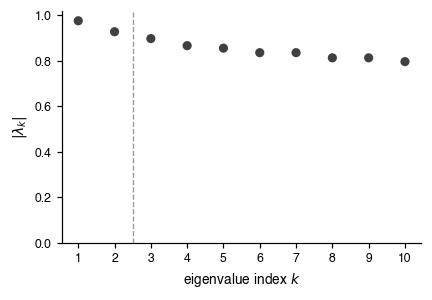

In [331]:

import os, sys, pickle, time
import numpy as np
import matplotlib.pyplot as plt

# Ensure slowmode/ is on the path.
sys.path.insert(0, os.path.abspath('.'))

import pipeline as pp
import gpcca_utils as gu
import figures as fg

fg.setup_style()
os.makedirs('outputs', exist_ok=True)

fig, ax = plt.subplots(figsize=(4.0, 2.8))
fg.plot_eigenvalue_dots(ax, evals[:10], M=M)
plt.tight_layout(); plt.show()


In [321]:
lag = int(tau_seconds * fs)
T = pp.make_transition_matrix(states_list, lag=lag, n_states=N)
pi = pp.stationary_distribution(T)
evals, evecs = pp.leading_eigvecs(T, k=10)
print(f'leading |lambda_k| = {np.abs(evals)[:6].round(4)}')

# Spectral gap selection of M.
M_pick, gap, ratios = gu.select_M_spectral_gap(evals, M_min=2, M_max=8)
print(f'spectral gap selects M = {M_pick} (ratio = {gap:.3f})')


leading |lambda_k| = [0.9757 0.9277 0.8975 0.8665 0.8555 0.8357]
spectral gap selects M = 2 (ratio = 1.052)


/var/folders/dk/ph3h6b9n1hg_hl057n5pp1mm0000gq/T/ipykernel_99886/2066822349.py:8: UserWarning: select_M_spectral_gap: ambiguous M -- the top two gap ratios (1.052, 1.036) are within 10%. Inspect the eigenvalue ladder and consider raising min_eigval.
  M_pick, gap, ratios = gu.select_M_spectral_gap(evals, M_min=2, M_max=8)


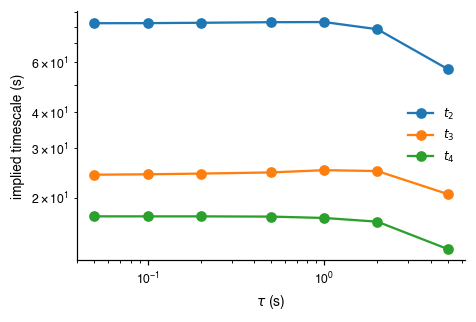

current choice: tau = 3 s
crispness    = 0.619
basin counts = [458  42]
pi per basin = [0.823 0.177]


In [332]:
lags_s = np.array([0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0])
implied = []
for ls_ in lags_s:
    lg = max(int(ls_ * fs), 1)
    Tt = pp.make_transition_matrix(states_list, lag=lg, n_states=N)
    e, _ = pp.leading_eigvecs(Tt, k=4)
    implied.append(-(lg / fs) / np.log(np.maximum(np.abs(e[:4]), 1e-12)))
implied = np.array(implied)
fig, ax = plt.subplots(figsize=(4.4, 3.0))
for k in range(3):
    ax.plot(lags_s, implied[:, k], 'o-', label=fr'$t_{{{k+2}}}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\tau$ (s)'); ax.set_ylabel('implied timescale (s)')
ax.legend()
plt.tight_layout(); plt.show()

print(f'current choice: tau = {tau_seconds} s')

out = gu.run_gpcca(T, M=M, eta=pi)
chi = out['chi']
print(f'crispness    = {out["crispness"]:.3f}')
print(f'basin counts = {out["basin_counts"]}')
print(f'pi per basin = {out["pi_basin"].round(3)}')



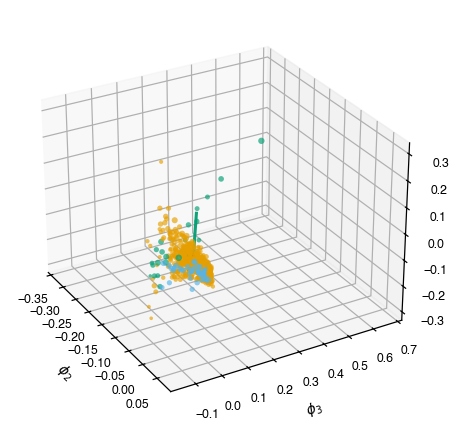

In [326]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
phi = evecs[:, 1:4].real
geo = gu.compute_hub_arms(phi, pi, chi)

fig = plt.figure(figsize=(4.6, 4.0))
ax = fig.add_subplot(111, projection='3d')
fg.plot_eigenspace_3d(ax, phi, pi=pi, chi=chi,
                       hub=geo['hub'], arm_dirs=geo['arm_dirs'],
                       arm_centroids=geo['arm_centroids'])

plt.tight_layout(); plt.show()


## Final Parameter Block

This cell is the single source of truth for the batch run. The batch defaults to all available species and can use all individuals by setting `batch_random_n_individuals = None`.


In [50]:
batch_species = available_species
batch_dataset = tuning_dataset
batch_stride = tuning_stride
batch_max_frames_per_recording = tuning_max_frames_per_recording
batch_random_n_individuals = 25
batch_random_seed = tuning_random_seed
fmax = 60

batch_parameters = {
    'd_embed': 7,
    'N': 200,
    'tau_seconds': tau_seconds,
    'M': M,
    'n_freqs': 20,
    'wavelet_subsample_factor': 50,
    'kmeans_subsample_factor': 25,
    'pca_max_components': 12,
    'n_shuffles': 3,
}

pd.Series(batch_parameters, name='value')


d_embed                       7.0
N                           200.0
tau_seconds                   5.0
M                             3.0
n_freqs                      20.0
wavelet_subsample_factor     50.0
kmeans_subsample_factor      25.0
pca_max_components           12.0
n_shuffles                    3.0
Name: value, dtype: float64

## Run Batch Species

This runs one species at a time. For each species, outputs are saved before moving on, including:

- `parameters.csv`
- `cluster_allocations_manifest.csv`
- `frame_cluster_assignments.csv`
- transfer operator/eigenvectors/G-PCCA outputs
- arms/eigenspace plots

The helper deletes large per-species objects and calls garbage collection between species.


In [32]:
run_batch = True

if run_batch:
    batch_summary_df = run_species_batch(
        species_names=batch_species,
        species_subjects_fn=species_subjects,
        select_manifest_fn=select_manifest,
        samplerate_fn=_samplerate,
        load_individual_trace_fn=load_individual_trace,
        dataset_name=batch_dataset,
        stride=1,
        max_frames_per_recording=batch_max_frames_per_recording,
        n_freqs=batch_parameters['n_freqs'],
        d_embed=batch_parameters['d_embed'],
        N=batch_parameters['N'],
        tau_seconds=batch_parameters['tau_seconds'],
        M=batch_parameters['M'],
        output_root='outputs/pooled_by_individual',
        random_n_individuals=batch_random_n_individuals,
        seed=batch_random_seed,
        wavelet_subsample_factor=batch_parameters['wavelet_subsample_factor'],
        kmeans_subsample_factor=batch_parameters['kmeans_subsample_factor'],
        pca_max_components=batch_parameters['pca_max_components'],
        n_shuffles=batch_parameters['n_shuffles'],
        kmeans_n_init=20,
        fmin=0.1,
        fmax_cap=60.0,
        verbose=True,
    )
    display(batch_summary_df)
else:
    print('Set run_batch = True when the parameters above are ready.')



=== Mus_caroli: 15 individuals ===
fs=120 Hz, f range=[0.1, 54] Hz
Pass 1/3: compute each individual's wavelets, keep every 50 row for shared PCA
  [1/15] CAROLI-F-N-740: X=(648024, 75)
  [2/15] CAROLI-M-R-738: X=(648024, 75)
  [3/15] CAROLI-F-LR-741: X=(648024, 75)
  [4/15] CAROLI-F-L-741: X=(648024, 75)
  [5/15] CAROLI-M-R-734: X=(648024, 75)
  [6/15] CAROLI-F-2L-741: X=(432016, 75)
  [7/15] CAROLI-F-R-737: X=(648024, 75)
  [8/15] CAROLI-M-N-739: X=(648024, 75)
  [9/15] CAROLI-F-R-741: X=(648024, 75)
  [10/15] CAROLI-M-LR-734: X=(432016, 75)
  [11/15] CAROLI-M-L-734: X=(648024, 75)
  [12/15] CAROLI-F-N-741: X=(648024, 75)
  [13/15] CAROLI-M-L-735: X=(648024, 75)
  [14/15] CAROLI-M-L-738: X=(648024, 75)
  [15/15] CAROLI-F-L-737: X=(648024, 75)
  PCA sample matrix = (185775, 1500)
  kept 12 PCs above threshold 51.1
Pass 2/2: recompute wavelets, project every frame onto shared PCA
  [1/15] CAROLI-F-N-740: projecting
  [2/15] CAROLI-M-R-738: projecting
  [3/15] CAROLI-F-LR-741: projecti

,species,dataset,n_individuals,individual_selection_seed,pipeline_stride,max_frames_per_recording,fs,fmin,fmax,n_freqs,...,M,gpcca_crispness,basin_counts,pi_basin,output_dir,parameters_csv,allocations_csv,transfer_operator_npy,arms_plot_png,frame_assignments_csv
0,Mus_caroli,size_normalized_coordinates,15,14,1,None,120.0,0.1,54.0,20,...,4,0.492299,"[123, 69, 5, 3]","[0.464263, 0.335815, 0.173299, 0.026622]",outputs/pooled_by_individual/Mus_caroli/final_...,outputs/pooled_by_individual/Mus_caroli/final_...,outputs/pooled_by_individual/Mus_caroli/final_...,outputs/pooled_by_individual/Mus_caroli/final_...,outputs/pooled_by_individual/Mus_caroli/final_...,outputs/pooled_by_individual/Mus_caroli/final_...
1,Mus_musculus,size_normalized_coordinates,25,14,1,None,120.0,0.1,54.0,20,...,4,0.491762,"[77, 59, 57, 7]","[0.390456, 0.261798, 0.252164, 0.095581]",outputs/pooled_by_individual/Mus_musculus/fina...,outputs/pooled_by_individual/Mus_musculus/fina...,outputs/pooled_by_individual/Mus_musculus/fina...,outputs/pooled_by_individual/Mus_musculus/fina...,outputs/pooled_by_individual/Mus_musculus/fina...,outputs/pooled_by_individual/Mus_musculus/fina...
2,Mus_spretus,size_normalized_coordinates,16,14,1,None,120.0,0.1,54.0,20,...,4,0.504999,"[79, 63, 44, 14]","[0.41168, 0.273471, 0.189936, 0.124913]",outputs/pooled_by_individual/Mus_spretus/final...,outputs/pooled_by_individual/Mus_spretus/final...,outputs/pooled_by_individual/Mus_spretus/final...,outputs/pooled_by_individual/Mus_spretus/final...,outputs/pooled_by_individual/Mus_spretus/final...,outputs/pooled_by_individual/Mus_spretus/final...
3,Peromyscus_californicus,size_normalized_coordinates,23,14,1,None,120.0,0.1,54.0,20,...,4,0.401055,"[92, 103, 1, 4]","[0.462694, 0.416871, 0.069322, 0.051114]",outputs/pooled_by_individual/Peromyscus_califo...,outputs/pooled_by_individual/Peromyscus_califo...,outputs/pooled_by_individual/Peromyscus_califo...,outputs/pooled_by_individual/Peromyscus_califo...,outputs/pooled_by_individual/Peromyscus_califo...,outputs/pooled_by_individual/Peromyscus_califo...
4,Peromyscus_gossypinus,size_normalized_coordinates,20,14,1,None,120.0,0.1,54.0,20,...,4,0.434548,"[95, 87, 5, 13]","[0.448653, 0.409938, 0.075395, 0.066014]",outputs/pooled_by_individual/Peromyscus_gossyp...,outputs/pooled_by_individual/Peromyscus_gossyp...,outputs/pooled_by_individual/Peromyscus_gossyp...,outputs/pooled_by_individual/Peromyscus_gossyp...,outputs/pooled_by_individual/Peromyscus_gossyp...,outputs/pooled_by_individual/Peromyscus_gossyp...
5,Peromyscus_leucopus,size_normalized_coordinates,14,14,1,None,120.0,0.1,54.0,20,...,4,0.494234,"[190, 1, 8, 1]","[0.684006, 0.160328, 0.100188, 0.055478]",outputs/pooled_by_individual/Peromyscus_leucop...,outputs/pooled_by_individual/Peromyscus_leucop...,outputs/pooled_by_individual/Peromyscus_leucop...,outputs/pooled_by_individual/Peromyscus_leucop...,outputs/pooled_by_individual/Peromyscus_leucop...,outputs/pooled_by_individual/Peromyscus_leucop...
6,Peromyscus_maniculatus,size_normalized_coordinates,25,14,1,None,120.0,0.1,54.0,20,...,4,0.407921,"[184, 9, 1, 6]","[0.725428, 0.129205, 0.102135, 0.043232]",outputs/pooled_by_individual/Peromyscus_manicu...,outputs/pooled_by_individual/Peromyscus_manicu...,outputs/pooled_by_individual/Peromyscus_manicu...,outputs/pooled_by_individual/Peromyscus_manicu...,outputs/pooled_by_individual/Peromyscus_manicu...,outputs/pooled_by_individual/Peromyscus_manicu...
7,Peromyscus_polionotus,size_normalized_coordinates,25,14,1,None,120.0,0.1,54.0,20,...,4,0.324396,"[123, 50, 23, 4]","[0.454977, 0.316732, 0.131123, 0.097168]",outputs/pooled_by_individual/Peromyscus_polion...,outputs/pooled_by_individual/Peromyscus_polion...,outputs/pooled_by_individual/Peromyscus_polion...,outputs/pooled_by_individual/Peromyscus_polion...,outputs/pooled_by_individual/Peromyscus_polion...,outputs/pooled_by_individual/Peromyscus_polion...


## Memory Cleanup After Tuning

Run this after tuning if you want to reclaim local notebook RAM before launching the batch.


In [ ]:
for name in ['X_tune', 'states_list', 'state_result']:
    if name in globals():
        del globals()[name]
plt.close('all')
gc.collect()
